## Our Framework Evaluation with Wisig Dataset

Dataset: [link](https://cores.ee.ucla.edu/downloads/datasets/wisig/)

In [ ]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import matlab
import cfo_utils
import utils
import matplotlib.pyplot as plt
from dataset_api import DatasetAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI
from extractor_api import ExtractorAPI
from dataset_preparation import ChannelIndSpectrogram
from scipy.spatial import distance
import random
import tensorflow as tf
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# DATASET_NAME =           DatasetAPI.DATASET_WISIG_OLD
DATASET_NAME =           DatasetAPI.DATASET_WISIG_NEW
RX_NODES =               [DatasetAPI.RX_1]
ROOT_DIRECTORY =         '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY =   '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting'
MATLAB_SESSION_ID =      'fp_workflow'
AUG_ON =                 False

DATA_CONFIG = {
    'dataset_name':      DATASET_NAME,
    'frame_count_train': 1000, # 200 for v2, 500 for v4, 500 for wisig
    'frame_count_epoch': 100,
    'samples_count':     400
}

AUG_CONFIG = {
    'multiplier':        5,
    't_rms_bounds':      matlab.double([1, 2]),
    'd_f_bounds':        matlab.double([0, 1]),
    'k_factor_bounds':   matlab.double([0, 1]),
    'awgn':              matlab.double([0, 1]),
}

2024-11-05 17:01:47.056610: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 17:01:47.056662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 17:01:47.057601: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 17:01:47.064072: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-05 17:01:47.791543: W tensorflow/compiler/tf2

In [2]:
def get_extractor_model(fp_api, ndays, augment_multiplier, enable_training, equalized, plot_history):
    if enable_training: 
        models, histories = fp_api.train_models_wisig_new(apply_noise=False, ndays=ndays, equalized=equalized, compensate_cfo=False, augment=True, augment_cfo=False, augment_multiplier=augment_multiplier)

        if plot_history:
            history = histories[RX_NODES[0]]
            plt.figure(figsize=(8, 6))
            plt.plot(history.history['loss'], label='Training Loss')
            plt.plot(history.history['val_loss'], label='Validation Loss')
            plt.title('Model Loss During Training')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.show()
    else: models = fp_api.load_models_wisig(is_new_dataset=True)
    return models[RX_NODES[0]]

def evaluate_extractor_wisig_closed_set(dataset_api, eval_api, model, day_enroll_i, day_identify_i, equalization_enabled, rssi_filtering_enabled, cfo_filtering_on, devices_disoint, show):
    # 1. Retrieve information about the WiSig dataset (device IDs, paths, etc)
    dataset_paths, _, _, node_ids_epoch, _ = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], RX_NODES[0], None, wisig_equalized=equalization_enabled, wisig_disjoint=devices_disoint)

    # Let's show devices used for enrollment / identification
    print(f'Enrollment devices: {node_ids_epoch}')

    # 2. Prepare signal & labels for enrollment subset
    data_enroll, labels_enroll, _ = dataset_api.load_raw_dataset(dataset_paths[day_enroll_i], shuffle=False)
    data_enroll, labels_enroll, _ = dataset_api.filter_dataset(data_enroll, labels_enroll, None, node_ids_epoch, pkt_range=range(300, 400))
    data_enroll = data_enroll[:, 0:DATA_CONFIG['samples_count']]
    # TODO: CFO compensation: disabled
    # TODO: CFO adding: disabled
    if rssi_filtering_enabled:
        data_enroll = ChannelIndSpectrogram()._normalization(data_enroll)
        rssi_enroll = np.array([utils.calculate_preamble_rssi(data_enroll[i, :]) for i in range(data_enroll.shape[0])])
        data_enroll, labels_enroll, _, _ = dataset_api.filter_frames_by_rssi(data_enroll, labels_enroll, rssi_enroll, device_frames=100, show_dist=False)
    if cfo_filtering_on:
        data_enroll, labels_enroll, _ = dataset_api.filter_frames_by_cfo(data_enroll, labels_enroll, None, show=False)

    # 3. Prepare signal & labels for identification subset
    data_id, labels_id, _ = dataset_api.load_raw_dataset(dataset_paths[day_identify_i], shuffle=False)
    data_id, labels_id, _ = dataset_api.filter_dataset(data_id, labels_id, None, node_ids_epoch, pkt_range=range(400, 500))
    data_id = data_id[:, 0:DATA_CONFIG['samples_count']]
    # TODO: CFO compensation: disabled
    # TODO: CFO adding: disabled
    if rssi_filtering_enabled:
        data_id = ChannelIndSpectrogram()._normalization(data_id)
        rssi_id = np.array([utils.calculate_preamble_rssi(data_id[i, :]) for i in range(data_id.shape[0])])
        data_id, labels_id, _, _ = dataset_api.filter_frames_by_rssi(data_id, labels_id, rssi_id, device_frames=100, show_dist=False)
    if cfo_filtering_on:
        data_id, labels_id, _ = dataset_api.filter_frames_by_cfo(data_id, labels_id, None, show=False)

    # 4. Perform closed-set data evaluation
    accuracy, real, pred = eval_api.evaluate_closed_set_knn(
        model, data_enroll, labels_enroll, data_id, labels_id, 
        k=10, fig_path='multirx_closed_set.eps' if show else None)

    if show:
        accuracy_label = "Disjoint Devices" if devices_disoint else "Joint Devices"
        print(f'{accuracy_label}. Closed-set classification accuracy: {np.round(accuracy*100, 2)}%')

    return accuracy, real, pred

### Let's evaluate loss function performance

1. To evaluate model performance, we'll be testing the extractor model with the following configurations:
    * Disjoint set of devices
    * Trained on Day 1
    * Enrolled on Day 1, identified on Day 4
    * Channel-independent spectrograms

2. We'll evaluate the most optimal alpha value for the triplet loss

3. We'll evaluate the most optimal alpha value for the quadruplet loss 

4. Finally, we'll plot both curves together and pick the loss function & alpha value that yields best model performance

In [ ]:
dataset_api = DatasetAPI(root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

alpha_values = np.arange(0.1, 2.0, 0.1)
loss_functions = ['triplet_loss', 'quadruplet_loss']

loss_results = np.zeros((len(loss_functions), len(alpha_values)))

for i, loss_function in enumerate(loss_functions):
    for j, alpha_value in enumerate(alpha_values):
        print(f'Evaluating loss={loss_function}, alpha={round(alpha_value, 1)}...')

        model_config = { 'loss_type': loss_function, 'alpha': alpha_value, 'fp_len': 512, 'row': 80, 'batch_size': 32, 'enable_ind': True }
        fp_api = FingerprintingAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=model_config, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
        eval_api = EvaluationAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=model_config, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

        extractor_model = get_extractor_model(fp_api, enable_training=True, equalized=False, plot_history=False, ndays=1, augment_multiplier=2)
        accuracy, _, _ = evaluate_extractor_wisig_closed_set(dataset_api, eval_api, extractor_model, 
                                                                day_enroll_i=0, day_identify_i=3, 
                                                                equalization_enabled=False, devices_disoint=True,
                                                                rssi_filtering_enabled=False, cfo_filtering_on=False, show=False)
        loss_results[i, j] = accuracy

        print(f'Loss: {loss_function}. Alpha: {alpha_value}. Closed-set Accuracy (disjoint, ch-ind): {round(accuracy, 2)}.')
        print('===============================================')

Evaluating loss=triplet_loss, alpha=0.1...
Training the model using data from 1 days.
Data raw: (22000, 400)
Data after filtering: (7600, 400)
Augmenting dataset: x2, randomized CFO adding disabled.
Data after augmentation: (15200, 400)
Final data: (15200, 400)
Epoch 1/1000
380/380 [==============================] - 12s 25ms/step - loss: 5.5559e-04 - val_loss: 1.1515e-04 - lr: 0.0010
Epoch 2/1000
380/380 [==============================] - 7s 20ms/step - loss: 8.4270e-05 - val_loss: 0.0000e+00 - lr: 0.0010
Epoch 3/1000
380/380 [==============================] - 7s 20ms/step - loss: 3.6814e-05 - val_loss: 3.2295e-06 - lr: 0.0010
Epoch 4/1000
380/380 [==============================] - 8s 20ms/step - loss: 1.7023e-05 - val_loss: 7.0913e-05 - lr: 0.0010
Epoch 5/1000
380/380 [==============================] - 8s 20ms/step - loss: 3.9239e-06 - val_loss: 0.0000e+00 - lr: 0.0010
Epoch 6/1000
380/380 [==============================] - 7s 19ms/step - loss: 0.0000e+00 - val_loss: 6.2440e-06 - lr: 

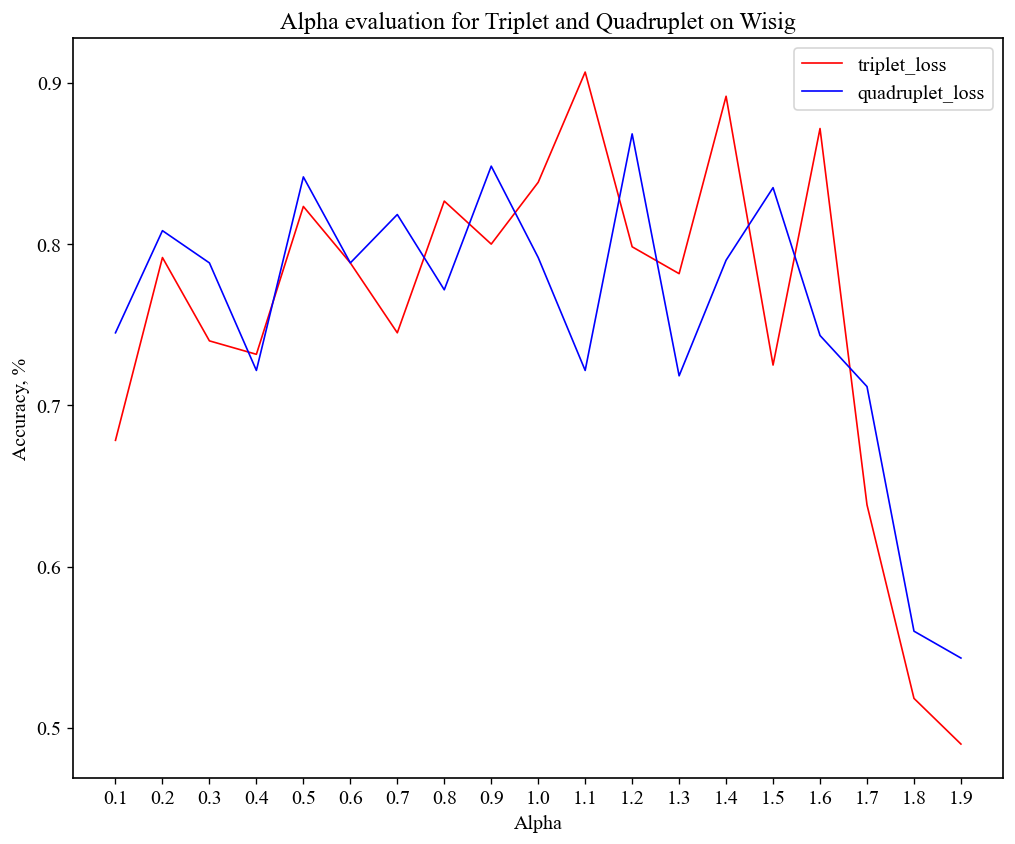

Max triplet loss accuracy: 0.91 (alpha=1.1)
Max quadruplet loss accuracy: 0.87 (alpha=1.2)


In [14]:
utils.apply_ieee_style()
plt.figure(figsize=(10, 8), dpi=120)
colors = ['red', 'blue']
for i, name in enumerate(loss_functions):
    plt.plot(loss_results[i, :], label=name, c=colors[i])
plt.title('Alpha evaluation for Triplet and Quadruplet on Wisig')
plt.ylabel('Accuracy, %')
plt.xlabel('Alpha')
plt.xticks(ticks=range(loss_results.shape[1]), labels=[f'{round(alpha,1)}' for alpha in alpha_values])
plt.legend()
plt.show()

print(f'Max triplet loss accuracy: {round(max(loss_results[0, :]), 2)} (alpha={round(alpha_values[np.argmax(loss_results[0, :])], 1)})')
print(f'Max quadruplet loss accuracy: {round(max(loss_results[1, :]), 2)} (alpha={round(alpha_values[np.argmax(loss_results[1, :])], 1)})')

### Let's evaluate Fingerprint Extractor model on WiSig dataset

The following parameters are being evaluated:
1. Signal transformation: raw, equalized, ch-ind, combined (equalized + ch-ind)
2. Enrollment / identification devices: joint, disjoint
3. Training days: 1, 1+2, 1+2+3

In [4]:
dataset_api = DatasetAPI(root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

# transformation_values = [{'eq': False, 'ch-ind': False}, {'eq': True, 'ch-ind': False}, {'eq': False, 'ch-ind': True}, {'eq': True, 'ch-ind': True}]
transformation_values = [{'eq': True, 'ch-ind': False}, {'eq': True, 'ch-ind': True}]
training_days = range(1, 4)
devices_disjoint = [False, True]
loss_function = 'triplet_loss'
loss_alpha = 1.1
day_enroll_i = 0
day_identify_i = 3
augment_multiplier=2

extractor_results_wisig = np.zeros((len(training_days), len(transformation_values), len(devices_disjoint)))

for i, training_days_item in enumerate(training_days):
    for j, transformation_item in enumerate(transformation_values):
        eq = transformation_item['eq']
        ch_ind = transformation_item['ch-ind']
        print(f'Parameters ndays={training_days_item}, equalized={eq}, ch-ind={ch_ind}')

        model_config = { 'loss_type': loss_function, 'alpha': loss_alpha, 'fp_len': 512, 'row': 80, 'batch_size': 32, 'enable_ind': transformation_item['ch-ind'] }
        fp_api = FingerprintingAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=model_config, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
        eval_api = EvaluationAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=model_config, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

        extractor_model = get_extractor_model(fp_api, enable_training=True, plot_history=False, equalized=eq, ndays=training_days_item, augment_multiplier=augment_multiplier)

        # There's np need to re-train the model for joint/disjoint testing
        for k, devices_disjoint_item in enumerate(devices_disjoint):
            print(f'Sub-parameter Disjoint={devices_disjoint_item}')
            
            accuracy, _, _ = evaluate_extractor_wisig_closed_set(dataset_api, eval_api, extractor_model, 
                                                                    day_enroll_i=day_enroll_i, day_identify_i=day_identify_i, 
                                                                    equalization_enabled=eq, devices_disoint=devices_disjoint_item,
                                                                    rssi_filtering_enabled=False, cfo_filtering_on=False, show=False)
            extractor_results_wisig[i, j, k] = accuracy

            print(f'Loss: {loss_function}. Alpha: {loss_alpha}. Closed-set Accuracy: {round(accuracy, 2)}.')
            print('===============================================')

# Print out the results after finishing the evaluation
for i, training_days_item in enumerate(training_days):
    for j, transformation_item in enumerate(transformation_values):
        for k, devices_disjoint_item in enumerate(devices_disjoint):
            eq = transformation_item['eq']
            ch_ind = transformation_item['ch-ind']
            print(f'Parameters ndays={training_days_item}, disjoint={devices_disjoint_item}, equalized={eq}, ch-ind={ch_ind}: {round(extractor_results_wisig[i, j, k], 2)}')

Parameters ndays=1, equalized=True, ch-ind=False
Training the model using data from 1 days.
Data raw: (22000, 400)
Data after filtering: (7600, 400)
Augmenting dataset: x2, randomized CFO adding disabled.
Data after augmentation: (15200, 400)
Final data: (15200, 400)
Epoch 1/1000
380/380 [==============================] - 12s 24ms/step - loss: 0.0957 - val_loss: 0.0142 - lr: 0.0010
Epoch 2/1000
380/380 [==============================] - 8s 20ms/step - loss: 0.0080 - val_loss: 0.0046 - lr: 0.0010
Epoch 3/1000
380/380 [==============================] - 8s 20ms/step - loss: 0.0037 - val_loss: 0.0022 - lr: 0.0010
Epoch 4/1000
380/380 [==============================] - 7s 19ms/step - loss: 0.0021 - val_loss: 0.0019 - lr: 0.0010
Epoch 5/1000
380/380 [==============================] - 7s 19ms/step - loss: 0.0014 - val_loss: 0.0011 - lr: 0.0010
Epoch 6/1000
380/380 [==============================] - 8s 21ms/step - loss: 0.0011 - val_loss: 0.0012 - lr: 0.0010
Epoch 7/1000
380/380 [=============

### Let's evaluate FP Extractor model (best parameters) on WiSig w.r.t. open-set challenge

This evaluation has two parts:
* Part 1: evaluate FP distances across devices
* Part 2: produce ROC curve for each day

#### Part 1. FP Distance Evaluation

When receiving new signal, we must determine whether we're dealing with a known or unknown (aka rogue) device.
To determine this, we must find the closest-matching fingerprint in the database and compare its distance to a pre-defined threshold.
If the distance is below the threshold -- we know this device. If it's above -- the device is new and we should add it to the system.

Here's how we can compare the successfullness of this binary classification across all available devices in our dataset. 

1. Train your best model on a set of training devices that will **not** be used for evaluation from Day N.
2. Select a set of **disjoint** devices from the same Day N. Use frames 0 -- 100 for enrollment. Use frames 100 -- 200 for identification.
3. Obtain fingerprints for all of the enrollment and all of the identification frames. 
4. Average them for each device, so that there was one fingerprint for each device enrollment and device identification.
5. Create fp_self_list, fp_closest_list
6. Perform the following actions for each device used for enrollment/identification:
    1. Find device's identification fingerprint
    2. Find device's enrollment fingerprint and distance De
    3. Find top #1 device match & fingerprint distance D1
    4. Find top #2 device match & fingerprint distance D2
    5. If device's enrollment FP == top #1 candidate:
        * append D1 to fp_self_list
        * append D2 to fp_closest_list
    6. Else:
        * append De to fp_self_list
        * append D1 to fp_closest_list
7. Plot both lines on a chart

Enrollment devices: [9, 11, 15, 17, 38, 57]
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.


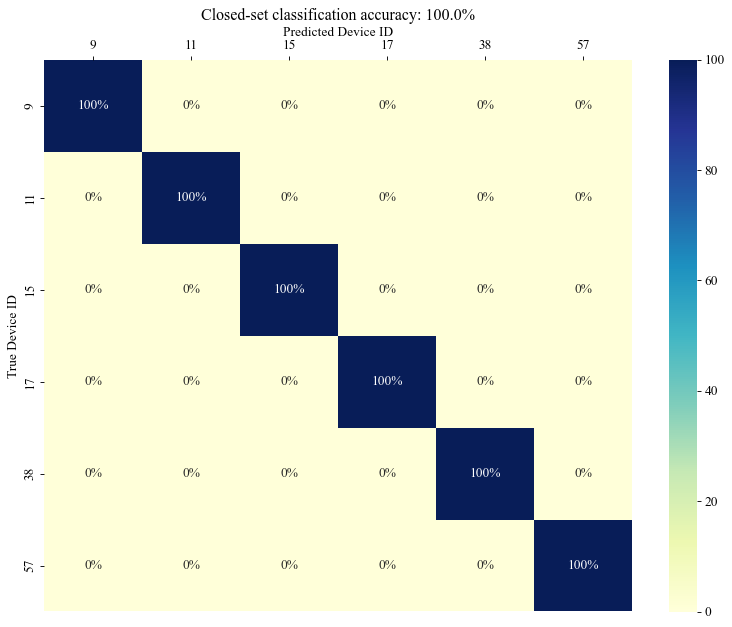

Disjoint Devices. Closed-set classification accuracy: 100.0%
Enrollment devices: [9, 11, 15, 17, 38, 57]
Enrollment devices: [9, 11, 15, 17, 38, 57]
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.


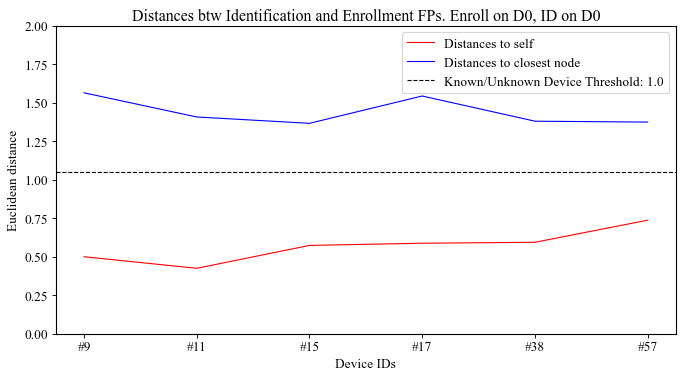

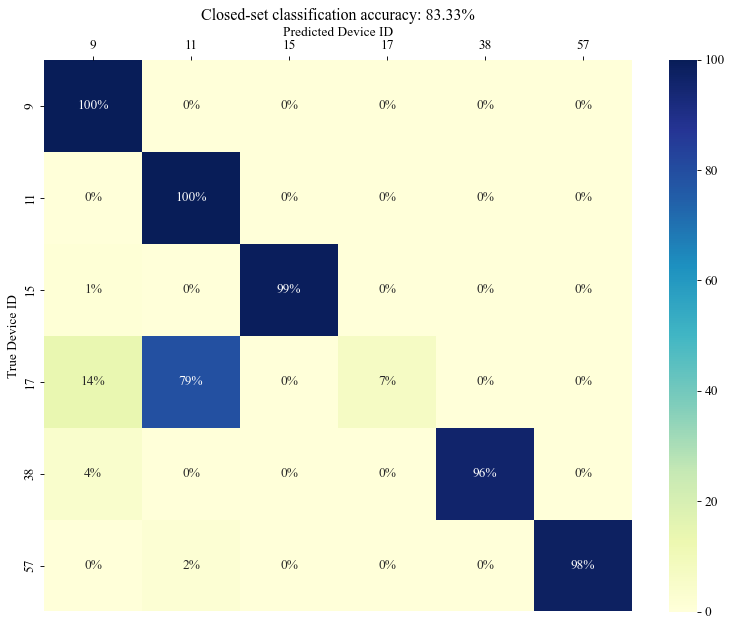

Disjoint Devices. Closed-set classification accuracy: 83.33%
Enrollment devices: [9, 11, 15, 17, 38, 57]
Enrollment devices: [9, 11, 15, 17, 38, 57]
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.


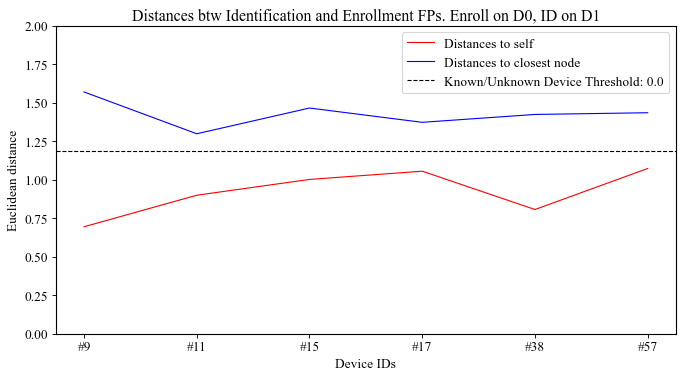

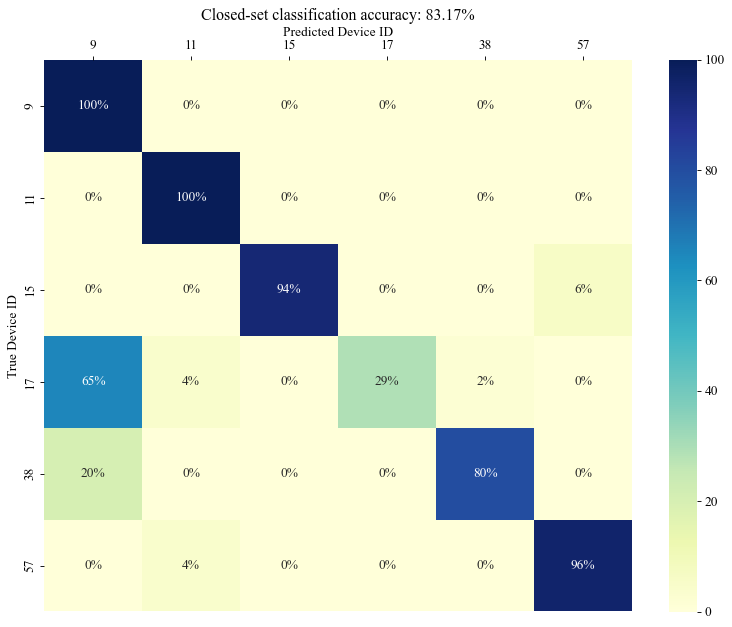

Disjoint Devices. Closed-set classification accuracy: 83.17%
Enrollment devices: [9, 11, 15, 17, 38, 57]
Enrollment devices: [9, 11, 15, 17, 38, 57]
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.


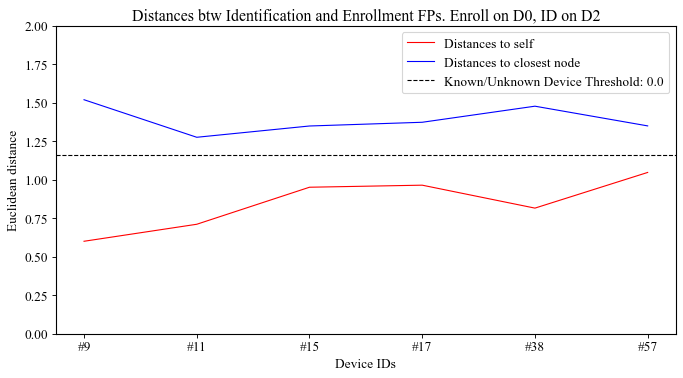

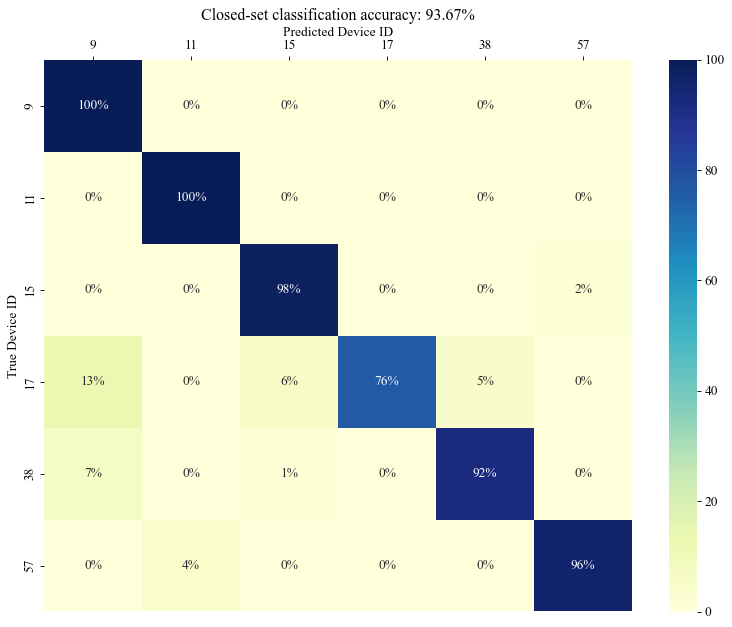

Disjoint Devices. Closed-set classification accuracy: 93.67%
Enrollment devices: [9, 11, 15, 17, 38, 57]


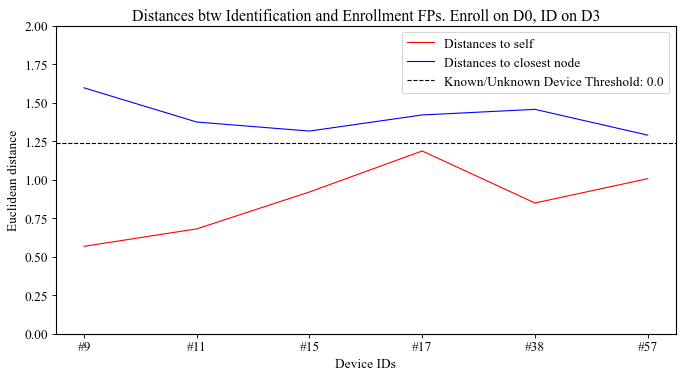

In [15]:
def evaluate_fp_distances_wisig(dataset_api, extractor_api, model, model_config, day_enroll_i, day_identify_i, equalization_enabled, rssi_filtering_enabled, cfo_filtering_on, devices_disoint):
    # 1. Retrieve information about the WiSig dataset (device IDs, paths, etc)
    dataset_paths, _, _, node_ids_epoch, _ = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], RX_NODES[0], None, wisig_equalized=equalization_enabled, wisig_disjoint=devices_disoint)

    # Let's show devices used for enrollment / identification
    print(f'Enrollment devices: {node_ids_epoch}')

    # 2. Prepare signal & labels for enrollment subset
    data_enroll, labels_enroll, _ = dataset_api.load_raw_dataset(dataset_paths[day_enroll_i], shuffle=False)
    data_enroll, labels_enroll, _ = dataset_api.filter_dataset(data_enroll, labels_enroll, None, node_ids_epoch, pkt_range=range(0, 100))
    data_enroll = data_enroll[:, 0:DATA_CONFIG['samples_count']]
    # TODO: CFO compensation: disabled
    # TODO: CFO adding: disabled
    if rssi_filtering_enabled:
        data_enroll = ChannelIndSpectrogram()._normalization(data_enroll)
        rssi_enroll = np.array([utils.calculate_preamble_rssi(data_enroll[i, :]) for i in range(data_enroll.shape[0])])
        data_enroll, labels_enroll, _, _ = dataset_api.filter_frames_by_rssi(data_enroll, labels_enroll, rssi_enroll, device_frames=100, show_dist=False)
    if cfo_filtering_on:
        data_enroll, labels_enroll, _ = dataset_api.filter_frames_by_cfo(data_enroll, labels_enroll, None, show=False)

    # 3. Prepare signal & labels for identification subset
    data_id, labels_id, _ = dataset_api.load_raw_dataset(dataset_paths[day_identify_i], shuffle=False)
    data_id, labels_id, _ = dataset_api.filter_dataset(data_id, labels_id, None, node_ids_epoch, pkt_range=range(400, 500))
    data_id = data_id[:, 0:DATA_CONFIG['samples_count']]
    # TODO: CFO compensation: disabled
    # TODO: CFO adding: disabled
    if rssi_filtering_enabled:
        data_id = ChannelIndSpectrogram()._normalization(data_id)
        rssi_id = np.array([utils.calculate_preamble_rssi(data_id[i, :]) for i in range(data_id.shape[0])])
        data_id, labels_id, _, _ = dataset_api.filter_frames_by_rssi(data_id, labels_id, rssi_id, device_frames=100, show_dist=False)
    if cfo_filtering_on:
        data_id, labels_id, _ = dataset_api.filter_frames_by_cfo(data_id, labels_id, None, show=False)

    # 4. Obtain fingerprints for each frame
    data_enroll_fps = extractor_api.run(model, data_enroll, model_config)
    data_id_fps = extractor_api.run(model, data_id, model_config)

    # 5. Average fingerprints for each device
    node_enroll_fps = {}
    node_id_fps = {}
    for node_id in node_ids_epoch:
        enroll_fps_idx = np.where(labels_enroll == node_id)[0]
        id_fps_idx = np.where(labels_id == node_id)[0]

        data_enroll_fps_node = data_enroll_fps[enroll_fps_idx, :]
        data_id_fps_node = data_id_fps[id_fps_idx, :]

        node_enroll_fps[node_id] = data_enroll_fps_node
        node_id_fps[node_id] = data_id_fps_node

    # 6. Produce the fingerprint distance vectors
    fp_self_distances = []
    fp_closest_distances = []
    for node_id in node_ids_epoch:
        closest_node_id = None
        closest_node_d = np.iinfo(np.int32).max
        
        for enroll_node_id in node_ids_epoch:
            d = np.mean(distance.cdist(node_id_fps[node_id], node_enroll_fps[enroll_node_id], 'euclidean'))

            if enroll_node_id == node_id: 
                fp_self_distances.append(d)
            elif not closest_node_id or d < closest_node_id:
                closest_node_id = enroll_node_id
                closest_node_d = d

        fp_closest_distances.append(closest_node_d)

    # 7. Calculate threshold
    threshold = np.mean([np.min(fp_closest_distances), np.max(fp_self_distances)])
    threshold_gap = np.max([0, np.min(fp_closest_distances) - np.max(fp_self_distances)])

    # 8. Plot fp distances
    plt.figure(figsize=(10, 5), dpi=80)
    plt.plot(fp_self_distances, c='red', label='Distances to self')
    plt.plot(fp_closest_distances, c='blue', label='Distances to closest node')
    plt.axhline(y=threshold, color='black', linestyle='--', label=f'Known/Unknown Device Threshold: {np.round(threshold_gap)}')
    plt.ylim(0, 2)
    plt.legend()
    plt.title(f'Distances btw Identification and Enrollment FPs. Enroll on D{day_enroll_i}, ID on D{day_identify_i}')
    plt.xlabel('Device IDs')
    plt.ylabel('Euclidean distance')
    plt.xticks(ticks=range(len(node_ids_epoch)), labels=[f'#{node_id}' for node_id in node_ids_epoch])

# Define parameters for the most effective model
eq = False
ch_ind = True
training_days = 1
devices_disjoint = True
loss_function = 'triplet_loss'
loss_alpha = 1.1
day_enroll_i = 0
day_identify_i = 3
augment_multiplier=2
pkt_range_enroll = range(0, 100)
pkt_range_identify = range(100, 200)
RX_NODES = [DatasetAPI.RX_1]

model_config = { 'loss_type': loss_function, 'alpha': loss_alpha, 'fp_len': 512, 'row': 80, 'batch_size': 32, 'enable_ind': ch_ind }
fp_api = FingerprintingAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=model_config, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
dataset_api = DatasetAPI(root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
eval_api = EvaluationAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=model_config, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
extractor_api = ExtractorAPI()

# Train the extractor model
extractor_model = get_extractor_model(fp_api, ndays=training_days, equalized=eq, plot_history=False, enable_training=False, augment_multiplier=2)

# Evaluate FP distances for each identification day
day_enroll = 0
for day_identify in range(4):
    evaluate_extractor_wisig_closed_set(dataset_api, eval_api, extractor_model, 
                                                         day_enroll_i=day_enroll, day_identify_i=day_identify, 
                                                         equalization_enabled=eq, devices_disoint=devices_disjoint,
                                                         rssi_filtering_enabled=False, cfo_filtering_on=False, show=True)

    evaluate_fp_distances_wisig(dataset_api, extractor_api, extractor_model, model_config, 
                                day_enroll_i=day_enroll, day_identify_i=day_identify, 
                                equalization_enabled=eq, rssi_filtering_enabled=False, 
                                cfo_filtering_on=False, devices_disoint=devices_disjoint)

#### Part 2. Produce ROC curve for each day



Enrollment devices: [9, 11, 15, 17, 38, 57]
Identification devices: [0, 129, 9, 11, 15, 17, 18, 25, 38, 300, 52, 57, 186, 190, 70, 200, 329, 84, 219, 100, 360, 361, 242, 378, 379]
Enrollment devices: [9, 11, 15, 17, 38, 57]
Identification devices: [129, 1, 9, 10, 11, 15, 17, 20, 152, 25, 38, 300, 52, 57, 189, 190, 329, 209, 213, 360, 361, 242, 378]
Enrollment devices: [9, 11, 15, 17, 38, 57]
Identification devices: [0, 1, 9, 11, 270, 15, 17, 21, 38, 57, 186, 189, 190, 70, 200, 209, 84, 213, 100, 360]
Enrollment devices: [9, 11, 15, 17, 38, 57]
Identification devices: [0, 1, 129, 9, 10, 11, 15, 17, 25, 38, 52, 57, 186, 70, 200, 329, 84, 216, 100, 242, 378, 379]


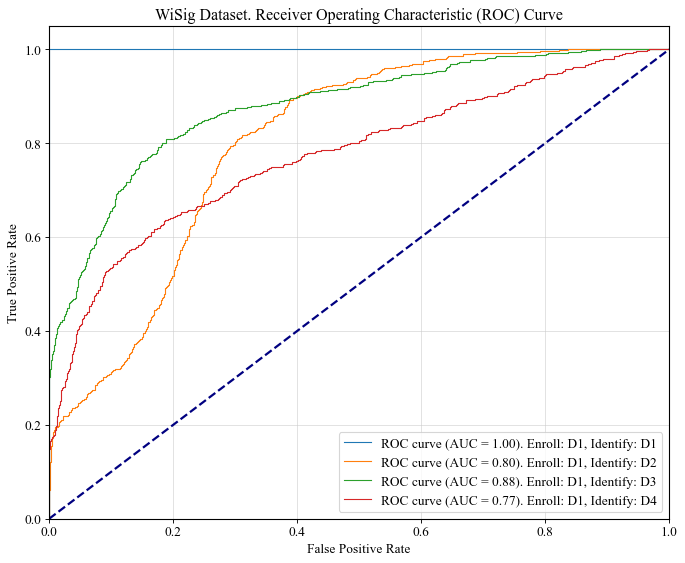

In [13]:
def evaluate_roc_wisig(dataset_api, extractor_api, model, model_config, day_enroll_i, day_identify_i, equalization_enabled, rssi_filtering_enabled, cfo_filtering_on, devices_disoint):
    # 1. Retrieve information about the WiSig dataset (device IDs, paths, etc)
    dataset_paths, _, node_ids_train, node_ids_enrollment, _ = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], RX_NODES[0], None, wisig_equalized=equalization_enabled, wisig_disjoint=devices_disoint)

    # 2. Prepare signal & labels for enrollment subset
    data_enroll, labels_enroll, _ = dataset_api.load_raw_dataset(dataset_paths[day_enroll_i], shuffle=False)
    data_enroll, labels_enroll, _ = dataset_api.filter_dataset(data_enroll, labels_enroll, None, node_ids_enrollment, pkt_range=range(0, 100))
    data_enroll = data_enroll[:, 0:DATA_CONFIG['samples_count']]
    # TODO: CFO compensation: disabled
    # TODO: CFO adding: disabled
    if rssi_filtering_enabled:
        data_enroll = ChannelIndSpectrogram()._normalization(data_enroll)
        rssi_enroll = np.array([utils.calculate_preamble_rssi(data_enroll[i, :]) for i in range(data_enroll.shape[0])])
        data_enroll, labels_enroll, _, _ = dataset_api.filter_frames_by_rssi(data_enroll, labels_enroll, rssi_enroll, device_frames=100, show_dist=False)
    if cfo_filtering_on:
        data_enroll, labels_enroll, _ = dataset_api.filter_frames_by_cfo(data_enroll, labels_enroll, None, show=False)

    # 3. Prepare signal & labels for identification subset
    data_id, labels_id, _ = dataset_api.load_raw_dataset(dataset_paths[day_identify_i], shuffle=False)
    node_ids_identification = list(set(labels_id.flatten()) - set(node_ids_train))
    data_id, labels_id, _ = dataset_api.filter_dataset(data_id, labels_id, None, node_ids_identification, pkt_range=range(400, 500))
    data_id = data_id[:, 0:DATA_CONFIG['samples_count']]
    # TODO: CFO compensation: disabled
    # TODO: CFO adding: disabled
    if rssi_filtering_enabled:
        data_id = ChannelIndSpectrogram()._normalization(data_id)
        rssi_id = np.array([utils.calculate_preamble_rssi(data_id[i, :]) for i in range(data_id.shape[0])])
        data_id, labels_id, _, _ = dataset_api.filter_frames_by_rssi(data_id, labels_id, rssi_id, device_frames=100, show_dist=False)
    if cfo_filtering_on:
        data_id, labels_id, _ = dataset_api.filter_frames_by_cfo(data_id, labels_id, None, show=False)

    # Let's show devices used for enrollment / identification
    print(f'Enrollment devices: {node_ids_enrollment}')
    print(f'Identification devices: {node_ids_identification}')

    # 4. Obtain fingerprints for each frame
    data_enroll_fps = extractor_api.run(model, data_enroll, model_config)
    data_id_fps = extractor_api.run(model, data_id, model_config)

    # 5. Compute closest distances
    distances = distance.cdist(data_id_fps, data_enroll_fps, 'euclidean') # produces a matrix M (ID fingerprints) x N (enroll fingerprints) distances
    closest_distances = np.min(distances, axis=1) # for each ID fingerprint, finds the min distance and leaves a vector M x 1

    # 6. Create binary ground truth labels (true if id label is in enroll dataset)
    y_true = np.isin(labels_id, labels_enroll)

    # 7. Euclidean distances are smaller for matching fingerprints, but ROC curve expects
    #    higher values for classes of higher likelihood of being positive; so we'll negate distances
    y_scores = -closest_distances

    # 8. Compute ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    return fpr, tpr

def plot_roc_curves(roc_curves):
    utils.apply_ieee_style()
    plt.figure(figsize=(10, 8), dpi=80)
    for roc_curve in roc_curves:
        fpr = roc_curve['fpr']
        tpr = roc_curve['tpr']
        label = roc_curve['info']
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f}). {label}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('WiSig Dataset. Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Define parameters for the most effective model
eq = False
ch_ind = True
training_days = 1
devices_disjoint = True
loss_function = 'triplet_loss'
loss_alpha = 1.1
day_enroll_i = 0
day_identify_i = 3
augment_multiplier=2
pkt_range_enroll = range(0, 100)
pkt_range_identify = range(100, 200)
RX_NODES = [DatasetAPI.RX_1]

model_config = { 'loss_type': loss_function, 'alpha': loss_alpha, 'fp_len': 512, 'row': 80, 'batch_size': 32, 'enable_ind': ch_ind }
fp_api = FingerprintingAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=model_config, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
dataset_api = DatasetAPI(root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
eval_api = EvaluationAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=model_config, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
extractor_api = ExtractorAPI()

# Train the extractor model
extractor_model = get_extractor_model(fp_api, ndays=training_days, equalized=eq, plot_history=False, enable_training=False, augment_multiplier=2)

# Evaluate FP distances for each identification day
day_enroll = 0
roc_curves = []
for day_identify in range(4):
    fpr, tpr = evaluate_roc_wisig(dataset_api, extractor_api, extractor_model, model_config, 
                                day_enroll_i=day_enroll, day_identify_i=day_identify, 
                                equalization_enabled=eq, rssi_filtering_enabled=False, 
                                cfo_filtering_on=False, devices_disoint=devices_disjoint)
    roc_curves.append({'tpr': tpr, 'fpr': fpr, 'info': f'Enroll: D{day_enroll+1}, Identify: D{day_identify+1}'})

plot_roc_curves(roc_curves)

In [16]:
A = [0, 129, 9, 11, 15, 17, 18, 25, 38, 300, 52, 57, 186, 190, 70, 200, 329, 84, 219, 100, 360, 361, 242, 378, 379]
B = [129, 1, 9, 10, 11, 15, 17, 20, 152, 25, 38, 300, 52, 57, 189, 190, 329, 209, 213, 360, 361, 242, 378]
C = [0, 1, 9, 11, 270, 15, 17, 21, 38, 57, 186, 189, 190, 70, 200, 209, 84, 213, 100, 360]
D = [0, 1, 129, 9, 10, 11, 15, 17, 25, 38, 52, 57, 186, 70, 200, 329, 84, 216, 100, 242, 378, 379]

utils.intersect_n(A, B, C, D)

[9, 11, 15, 17, 38, 57]

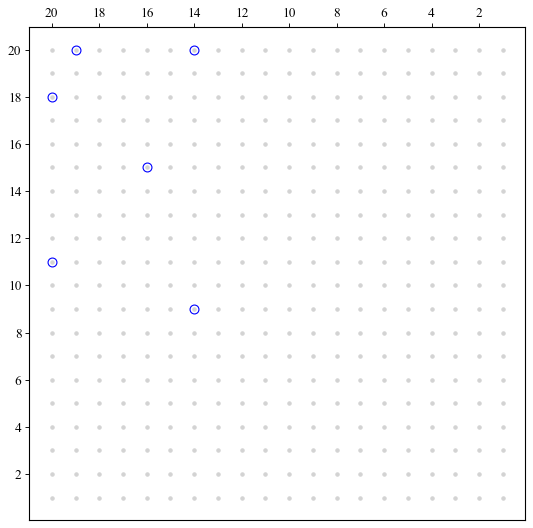

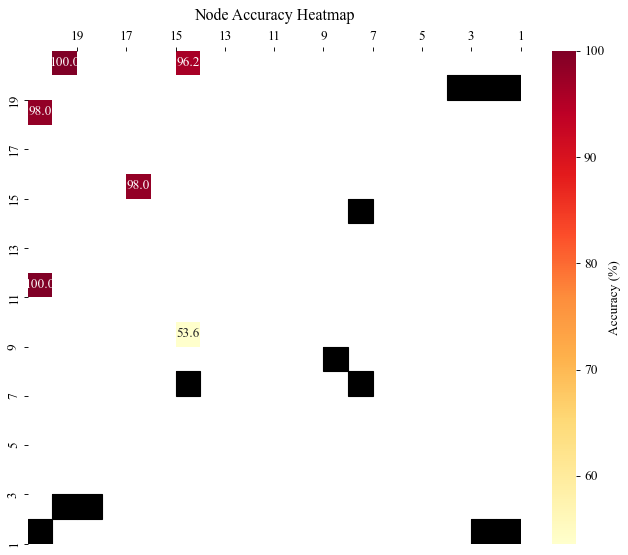

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
from typing import List, Dict
import seaborn as sea

def get_per_class_accuracy(y_true, y_pred):
    # Convert to numpy arrays if they aren't already
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Get precision for each class (precision == accuracy for each class)
    precision, _, _, _ = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
    
    # Get unique labels
    labels = np.unique(y_true)
    
    # Create dictionary mapping labels to their accuracies
    accuracies = {str(label): round(prec * 100, 2) 
                 for label, prec in zip(labels, precision)}
    
    return accuracies

node_id_accuracies = get_per_class_accuracy(real, pred)
_, node_coordinates = utils.generate_grid_node_ids()
node_coord_accuracies = {}
for node_id in node_id_accuracies.keys():
    node_coord_str = node_coordinates[int(node_id)]
    node_coord_accuracies[node_coord_str] = node_id_accuracies[node_id]

grid_accuracies = np.zeros((20, 20))

plt.figure(figsize=(8, 8), dpi=80)
for i in np.arange(1, 21):
    for j in np.arange(1, 21):
        node = (i, j)

        plt.plot(i, j, '.', color='#D3D3D3')

        if (i, j) in node_coord_accuracies.keys():
            grid_accuracies[i-1, j-1] = node_coord_accuracies[(i, j)]
            plt.plot(i, j, 'o', markerfacecolor='none', markeredgecolor='blue', markersize=8)
        else: 
            grid_accuracies[i-1, j-1] = -1


# plt.plot(1, 1, 'o', color='black', markersize=10)
plt.xticks(np.arange(2, 21, 2))
plt.yticks(np.arange(2, 21, 2))
ax = plt.gca()
ax.invert_xaxis()
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.show()

wisig_tx_coordinates = [(1, 1),(1, 19),(14, 7),(18, 2),(19, 2),(2, 1),(2, 19),(20, 1),(3, 19),(7, 14),(7, 7),(8, 8)]
for x, y in wisig_tx_coordinates:
    grid_accuracies[x-1, y-1] = -100

# grid_accuracies[0, 0] = -100

##################

grid_accuracies = np.swapaxes(grid_accuracies, 0, 1)

from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from typing import List, Dict
import seaborn as sea
import numpy as np
import matplotlib.pyplot as plt

# Create two masks - one for -1 values (white) and one for -100 values (black)
mask_white = grid_accuracies == -1
mask_black = grid_accuracies == -100

# Create a copy of the data where we replace -100 with the maximum value
# (This ensures it gets the darkest color in our colormap)
grid_accuracies_modified = grid_accuracies.copy()
grid_accuracies_modified[mask_black] = np.nanmax(grid_accuracies[~mask_white & ~mask_black])

# Create custom annotation array
annot = np.zeros_like(grid_accuracies, dtype='object')
for i in range(grid_accuracies.shape[0]):
    for j in range(grid_accuracies.shape[1]):
        if grid_accuracies[i, j] != -1 and grid_accuracies[i, j] != -100:
            annot[i, j] = f'{grid_accuracies[i, j]:.1f}'
        else:
            annot[i, j] = ''

plt.figure(figsize=(10, 8), dpi=80)

# Create the base heatmap with white spaces for -1
ax = sea.heatmap(grid_accuracies_modified,
                 cmap='YlOrRd',
                 annot=annot,
                 fmt='',
                 cbar_kws={'label': 'Accuracy (%)'},
                 square=True,
                 xticklabels=np.arange(1, 21),
                 yticklabels=np.arange(1, 21),
                 mask=mask_white)  # Mask for white spaces

# Add black patches for -100 values
for i in range(grid_accuracies.shape[0]):
    for j in range(grid_accuracies.shape[1]):
        if grid_accuracies[i, j] == -100:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color='black'))

# Invert x-axis and y-axis
ax.invert_xaxis()
ax.invert_yaxis()

# Move x-axis to top
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

# Set the aspect ratio to be equal
ax.set_aspect('equal')

# Set tick frequency
plt.xticks(np.arange(0, 20, 2), np.arange(1, 21, 2))
plt.yticks(np.arange(0, 20, 2), np.arange(1, 21, 2))

plt.title('Node Accuracy Heatmap', pad=10)

plt.show()

In [9]:
import pickle

def load_compact_pkl_dataset(dataset_path,dataset_name):
    with open(dataset_path+dataset_name+'.pkl','rb') as f:
        dataset = pickle.load(f)
    return dataset

dataset = load_compact_pkl_dataset('/home/smazokha2016/Downloads/','ManySig')

dataset['rx_list']

['1-1',
 '1-19',
 '14-7',
 '18-2',
 '19-2',
 '2-1',
 '2-19',
 '20-1',
 '3-19',
 '7-14',
 '7-7',
 '8-8']

<!--  -->

### Little Experiment with CFO on WiSig

Let's evaluate what the CFO values look like for different devices across days (using raw non-equalized data). 

If there's major volatility -- maybe there's correlation between that volatility and devices that are often misclassified?..

In [16]:
# data, labels, rssi = dataset_api.load_raw_dataset('/home/smazokha2016/Desktop/wisig_dataset_new/node1-1_wifi_2021_03_01_e0:06:e6:18:45:cf.h5', shuffle=False)
data, labels, rssi = dataset_api.load_raw_dataset('/home/smazokha2016/Desktop/wisig_dataset_new/node1-1_wifi_2021_03_08.h5', shuffle=False)

In [17]:
print(set(labels.flatten()))
print(data.shape)

{1, 133, 398, 80, 114, 52, 152}
(7000, 400)


In [26]:
compare_a = set([9, 11, 15, 17, 25, 38, 52, 57, 60, 69, 80, 84, 129, 130, 133, 142, 147, 157, 190, 196, 203, 206, 239, 242, 280, 300, 315, 329, 330, 360, 378, 380, 391])
compare_b = set(labels.flatten())

for item in compare_a:
    if item not in compare_b: print(item)

In [ ]:
node_names = ['14-10', '14-7', '20-15', '20-19', '6-15', '8-20']
def generate_node_ids():
    ids = {}
    node_i = 0
    for i in np.arange(1, 21):
        for j in np.arange(1, 21):
            ids[str(i) + "-" + str(j)] = node_i
            node_i = node_i + 1
    return ids

node_ids_dict = generate_node_ids()
node_ids_present_set = set(labels.flatten())

for item in node_names:
    present = node_ids_dict[item] in node_ids_present_set
    print(f"{item}: {node_ids_dict[item]}: {present}")


14-10: 269: True
14-7: 266: True
20-15: 394: True
20-19: 398: True
6-15: 114: True
8-20: 159: True


Not removing CFO.
Not removing CFO.
Not removing CFO.
Not removing CFO.


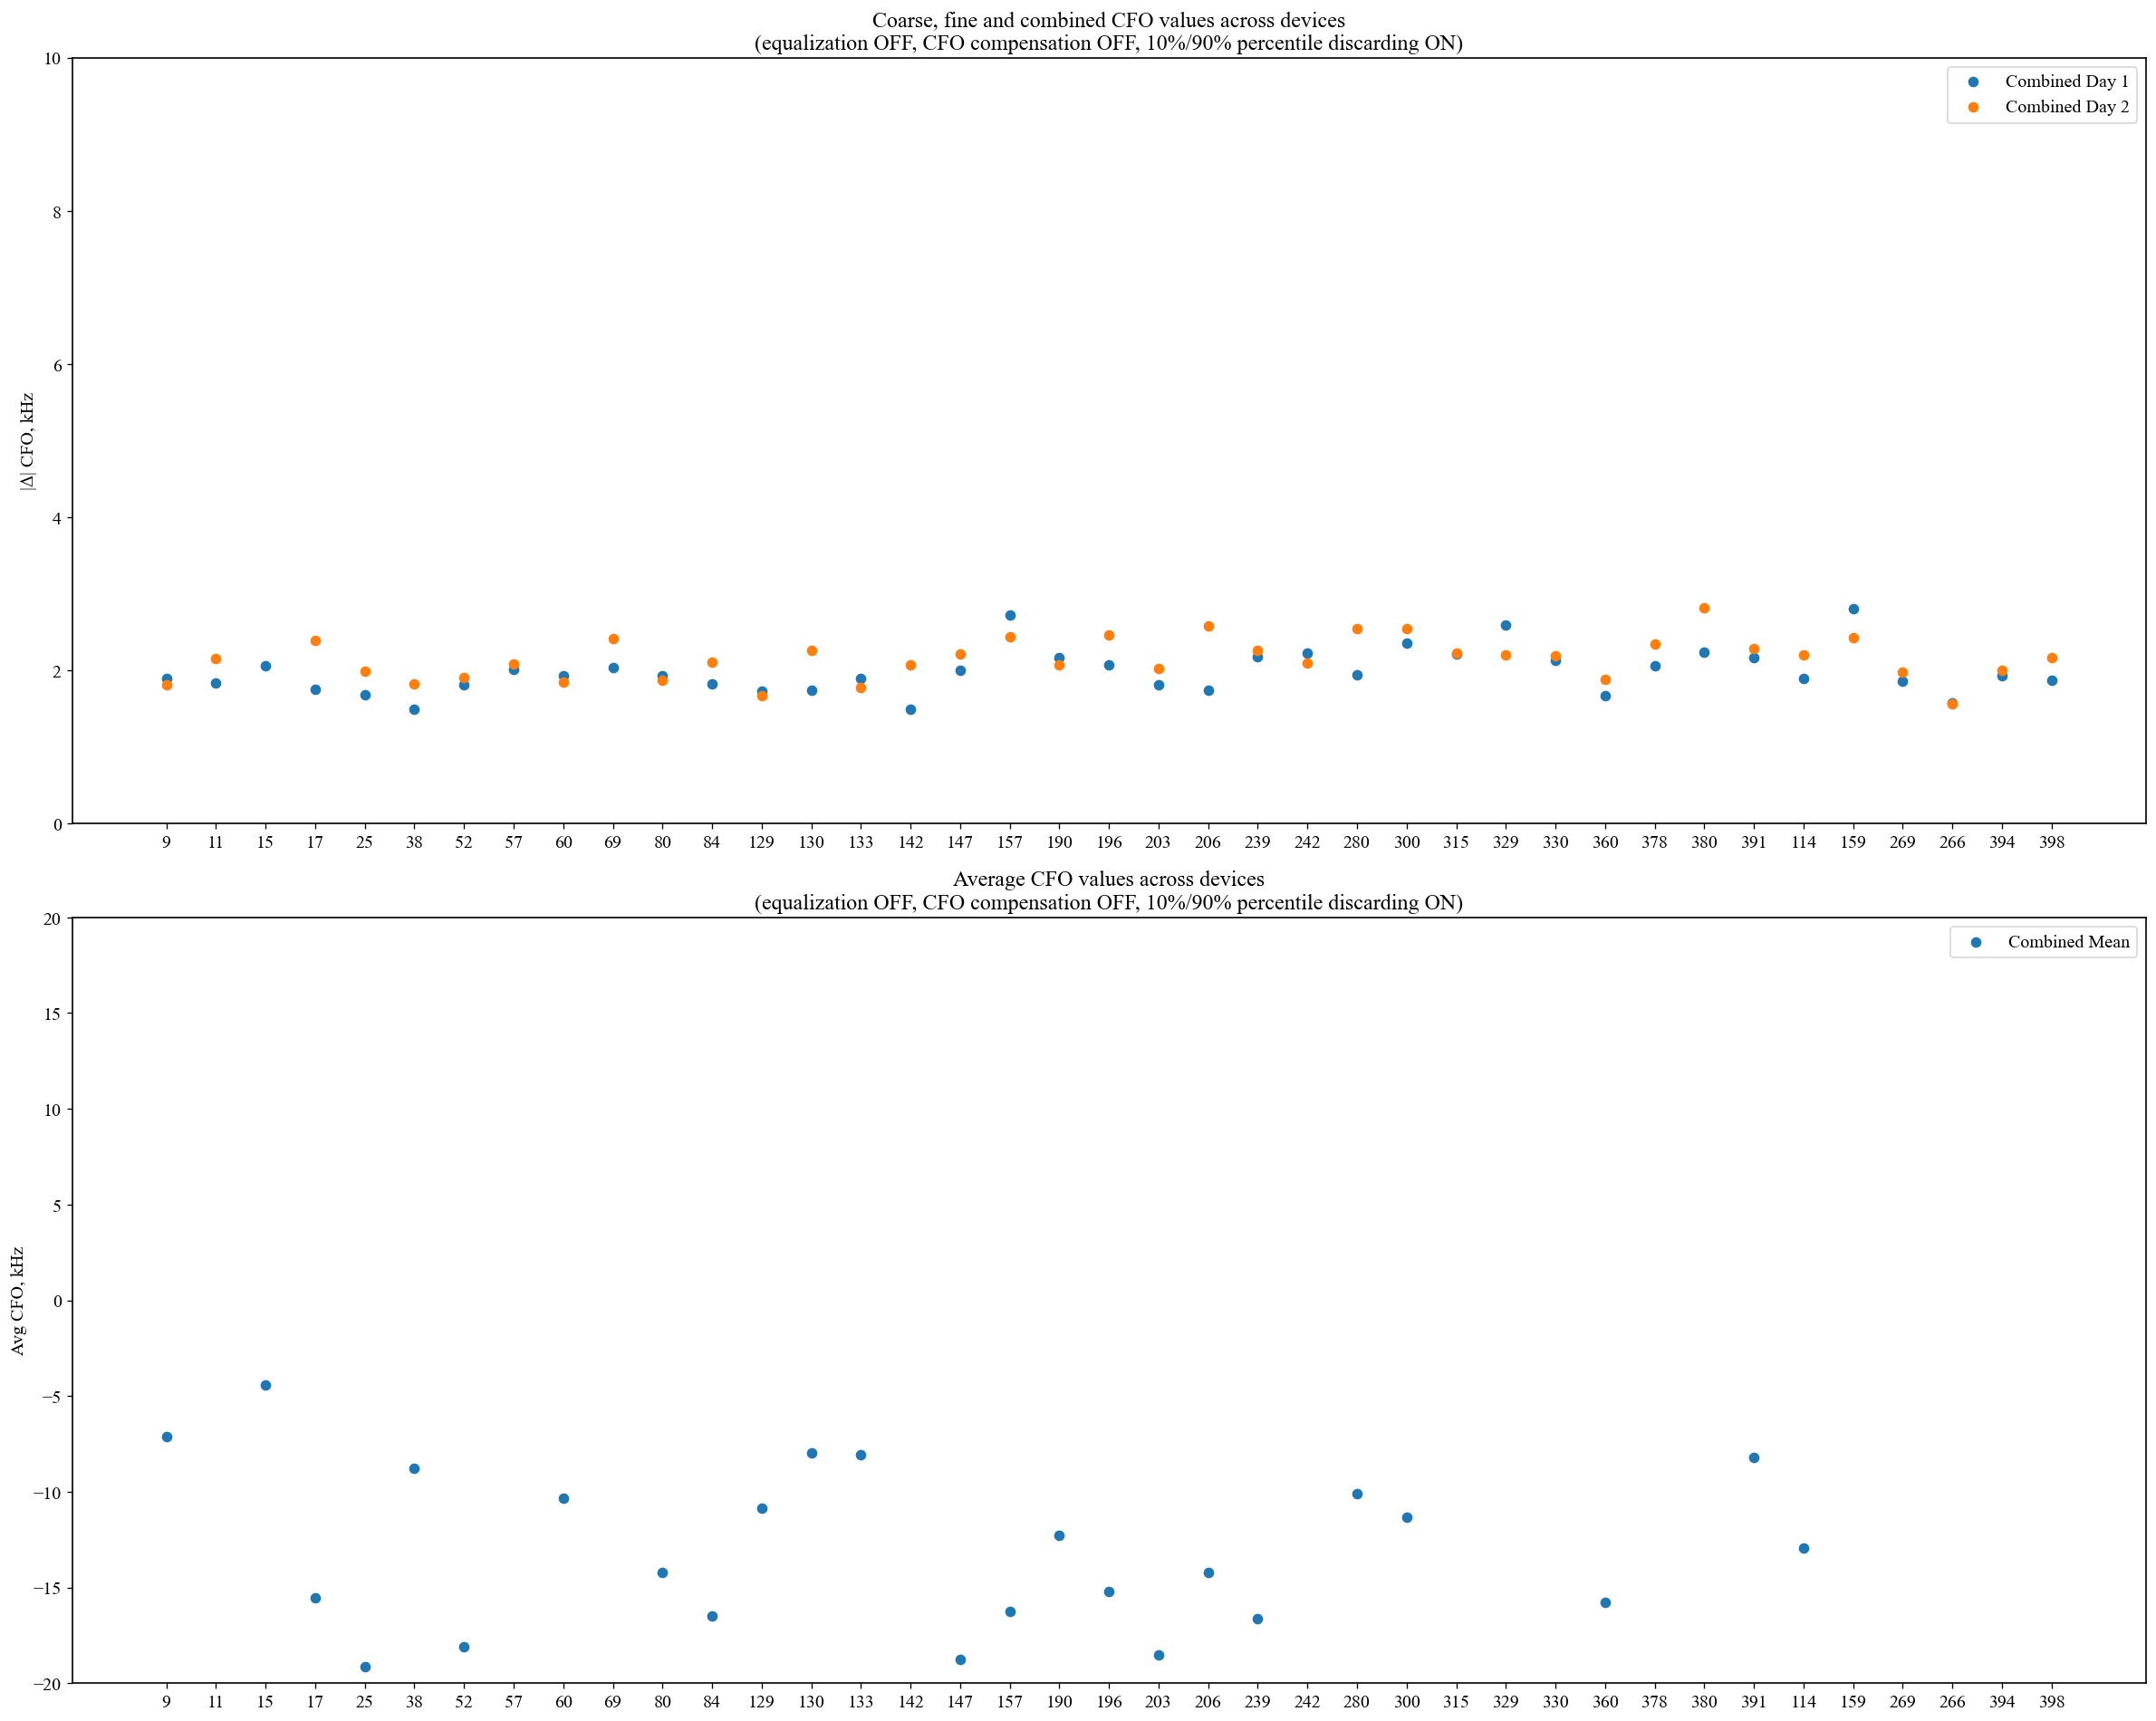

In [ ]:

equalization_on = False
cfo_compensation_on = False
cfo_frame_discarding_on = True

route_chunk = 'eq' if equalization_on else 'non_eq'

data_raw_11, label_raw_11, _ = dataset_api.load_raw_dataset_wisig(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_old_1rx/wisig_dataset-2021_03_01/Train/node1-1_{route_chunk}_train.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)
data_raw_12, label_raw_12, _ = dataset_api.load_raw_dataset_wisig(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_old_1rx/wisig_dataset-2021_03_01/Test/{route_chunk}_epoch_2021-03-01_00-00-00.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)
data_raw_21, label_raw_21, _ = dataset_api.load_raw_dataset_wisig(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_old_1rx/wisig_dataset-2021_03_08/Train/node1-1_{route_chunk}_train.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)
data_raw_22, label_raw_22, _ = dataset_api.load_raw_dataset_wisig(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_old_1rx/wisig_dataset-2021_03_08/Test/{route_chunk}_epoch_2021-03-08_00-00-00.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)

data_raw_1, label_raw_1 = combine_datasets(datas=[data_raw_11, data_raw_12], labels=[label_raw_11, label_raw_12])
data_raw_2, label_raw_2 = combine_datasets(datas=[data_raw_21, data_raw_22], labels=[label_raw_21, label_raw_22])

# Training devices
# Note: these are not all devices available in WiSig. This is a union between devices available on Day 1 and Day 2.
train_device_ids = [9, 11, 15, 17, 25, 38, 52, 57, 60, 69, 80, 84, 129, 130, 133, 142, 147, 157, 190, 196, 203, 206, 239, 242, 280, 300, 315, 329, 330, 360, 378, 380, 391]
# Testing devices: disjoint set
test_device_ids_disjoint = [114, 159, 269, 266, 394, 398]
# Testing devices: joint set (subset of training)
test_device_ids_joint = [9, 11, 15, 17, 25, 38]
# Combined joint and disjoint
combined_device_ids = train_device_ids + test_device_ids_disjoint

device_ids = combined_device_ids

coarse_day1_deltas = []
coarse_day2_deltas = []
coarse_means = []
fine_day1_deltas = []
fine_day2_deltas = []
fine_means = []
combined_day1_deltas = []
combined_day2_deltas = []
combined_means = []
combined_maxes = []
combined_mins = []

# plt.figure(figsize=(10, 8), dpi=80)
for device_id in device_ids:
    data_raw_1_dev, label_raw_1_dev, _ = dataset_api.filter_dataset(data_raw_1, label_raw_1, None, dev_range=[device_id], pkt_range=np.arange(0, 500))
    data_raw_2_dev, label_raw_2_dev, _ = dataset_api.filter_dataset(data_raw_2, label_raw_2, None, dev_range=[device_id], pkt_range=np.arange(0, 500))

    if cfo_frame_discarding_on:
        data_raw_1_dev, _, _ = dataset_api.filter_frames_by_cfo(data_raw_1_dev, label_raw_1_dev, None, show=False)
        data_raw_2_dev, _, _ = dataset_api.filter_frames_by_cfo(data_raw_2_dev, label_raw_2_dev, None, show=False)

    # Estimate coarse and fine CFO, and convert to kHz (divide by 1000)
    cfo_1 = cfo_utils.extract_data_cfo(data_raw_1_dev) / 1000
    cfo_2 = cfo_utils.extract_data_cfo(data_raw_2_dev) / 1000
    cfo_comb = np.vstack((cfo_1, cfo_2))
    
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 0], label=f"Coarse. Device ID: {device_id}")
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 1], label=f"Fine. Device ID: {device_id}")
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 0] + cfo_comb[:, 1], label=f"Combined. Device ID: {device_id}")

    coarse_day1_min = min(cfo_1[:, 0])
    coarse_day1_max = max(cfo_1[:, 0])
    coarse_day1_delta = abs(coarse_day1_max - coarse_day1_min)
    coarse_day2_min = min(cfo_2[:, 0])
    coarse_day2_max = max(cfo_2[:, 0])
    coarse_day2_delta = abs(coarse_day2_max - coarse_day2_min)
    coarse_mean = np.mean(cfo_comb[:, 0])

    fine_day1_min = min(cfo_1[:, 1])
    fine_day1_max = max(cfo_1[:, 1])
    fine_day1_delta = abs(fine_day1_max - fine_day1_min)
    fine_day2_min = min(cfo_2[:, 1])
    fine_day2_max = max(cfo_2[:, 1])
    fine_day2_delta = abs(fine_day2_max - fine_day2_min)
    fine_mean = np.mean(cfo_comb[:, 1])

    combined_day1_min = min(cfo_1[:, 0] + cfo_1[:, 1])
    combined_day1_max = max(cfo_1[:, 0] + cfo_1[:, 1])
    combined_day1_delta = abs(combined_day1_max - combined_day1_min)
    combined_day2_min = min(cfo_2[:, 0] + cfo_2[:, 1])
    combined_day2_max = max(cfo_2[:, 0] + cfo_2[:, 1])
    combined_day2_delta = abs(combined_day2_max - combined_day2_min)
    combined_mean = np.mean(cfo_comb[:, 0] + cfo_comb[:, 1])

    coarse_day1_deltas.append(coarse_day1_delta)
    coarse_day2_deltas.append(coarse_day2_delta)
    coarse_means.append(coarse_mean)
    fine_day1_deltas.append(fine_day1_delta)
    fine_day2_deltas.append(fine_day2_delta)
    fine_means.append(fine_mean)
    combined_day1_deltas.append(combined_day1_delta)
    combined_day2_deltas.append(combined_day2_delta)
    combined_means.append(combined_mean)
    combined_maxes.append(max(combined_day1_max, combined_day2_max))
    combined_mins.append(min(combined_day1_min, combined_day2_min))
    
    # print(f'Device #{device_id}. Coarse CFO:')
    # print(f'- Day 1. min: {round(coarse_day1_min, 2)} kHz. max: {round(coarse_day1_max, 2)} kHz. Δ: {round(coarse_day1_delta, 2)} kHz')
    # print(f'- Day 2. min: {round(coarse_day2_min, 2)} kHz. max: {round(coarse_day2_max, 2)} kHz. Δ: {round(coarse_day2_delta, 2)} kHz')
    # print(f'Device #{device_id}. Fine CFO:')
    # print(f'- Day 1. min: {round(fine_day1_min, 2)} kHz. max: {round(fine_day1_max, 2)} kHz. Δ: {round(fine_day1_delta, 2)} kHz')
    # print(f'- Day 2. min: {round(fine_day2_min, 2)} kHz. max: {round(fine_day2_max, 2)} kHz. Δ: {round(fine_day2_delta, 2)} kHz')
    # print(f'Device #{device_id}. Combined CFO:')
    # print(f'- Day 1. min: {round(combined_day1_min, 2)} kHz. max: {round(combined_day1_max, 2)} kHz. Δ: {round(combined_day1_delta, 2)} kHz')
    # print(f'- Day 2. min: {round(combined_day2_min, 2)} kHz. max: {round(combined_day2_max, 2)} kHz. Δ: {round(combined_day2_delta, 2)} kHz')
    # print('===================================================================')

# plt.legend()
# plt.ylim(-20, 20)
# plt.xlabel('Sample Index. Day 1: 400-499. Day 2: 400-499.')
# plt.ylabel('Absolute CFO Values, kHz')
# plt.show()

device_count = len(device_ids)
title_equalization = "ON" if equalization_on else "OFF"
title_cfo_compensation = "ON" if cfo_compensation_on else "OFF"
title_cfo_filtering = "ON" if cfo_frame_discarding_on else "OFF"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 16), dpi=120)

# First subplot (deltas)
# ax1.scatter(range(device_count), coarse_day1_deltas, label='Coarse Day 1')
# ax1.scatter(range(device_count), coarse_day2_deltas, label='Coarse Day 2')
# ax1.scatter(range(device_count), fine_day1_deltas, label='Fine Day 1')
# ax1.scatter(range(device_count), fine_day2_deltas, label='Fine Day 2')
ax1.scatter(range(device_count), combined_day1_deltas, label='Combined Day 1')
ax1.scatter(range(device_count), combined_day2_deltas, label='Combined Day 2')
ax1.set_xticks(range(device_count))
ax1.set_xticklabels(device_ids)
ax1.legend()
ax1.set_ylabel('|Δ| CFO, kHz')
ax1.set_ylim(0, 10)
ax1.set_title(f'Coarse, fine and combined CFO values across devices\n(equalization {title_equalization}, CFO compensation {title_cfo_compensation}, 10%/90% percentile discarding {title_cfo_filtering})')

# Second subplot (means)
# ax2.scatter(range(device_count), coarse_means, label='Coarse Mean')
# ax2.scatter(range(device_count), fine_means, label='Fine Mean')
ax2.scatter(range(device_count), combined_means, label='Combined Mean')
ax2.set_xticks(range(device_count))
ax2.set_xticklabels(device_ids)
ax2.legend()
ax2.set_ylabel('Avg CFO, kHz')
ax2.set_ylim(-20, 20)
ax2.set_title(f'Average CFO values across devices\n(equalization {title_equalization}, CFO compensation {title_cfo_compensation}, 10%/90% percentile discarding {title_cfo_filtering})')

# Adjust the spacing between subplots
plt.tight_layout()
plt.show()